# Default SVM, RF, and LR

In [87]:
# Importing the relevant tools used to create the SVM, RF, and diagrams
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, recall_score, 
                             roc_auc_score, classification_report, ConfusionMatrixDisplay)
import zipfile

# Loading the data by unzipping the file
zip_path = "/Users/seanrampersad/downloads/breast_cancer_wisconsin_diagnostic.zip"
extract_path = "data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".data") or file.endswith(".csv"):
            data_file = os.path.join(root, file)

# Defining columns manually as the raw WDBC data files lack a header row
columns = [
    "id","diagnosis",
    "radius_mean","texture_mean","perimeter_mean","area_mean","smoothness_mean",
    "compactness_mean","concavity_mean","concave_points_mean","symmetry_mean","fractal_dimension_mean",
    "radius_se","texture_se","perimeter_se","area_se","smoothness_se",
    "compactness_se","concavity_se","concave_points_se","symmetry_se","fractal_dimension_se",
    "radius_worst","texture_worst","perimeter_worst","area_worst","smoothness_worst",
    "compactness_worst","concavity_worst","concave_points_worst","symmetry_worst","fractal_dimension_worst"
]

# Loading the data into a pandas DataFrame
df = pd.read_csv(data_file, header=None, names=columns)

# Converting categorical 'diagnosis' (M/B) into numeric values (1/0) for the model
label_e = LabelEncoder()
df['diagnosis'] = label_e.fit_transform(df['diagnosis'])

# Separate features (X) from the target label (y) and drop the unique 'id' column
X = df.drop(['id', 'diagnosis'], axis=1)
y = df['diagnosis']

# Split the data into Training (80%) and Testing (20%) sets
# The 'stratify' function ensures the proportion of Malignant/Benign cases is consistent in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Standardizing features for model to learn from
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the primary models using optimized parameters
best_estimators = {
    'Logistic Regression': LogisticRegression(C=1, solver='liblinear', random_state=42).fit(X_train_scaled, y_train),
    'Random Forest': RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42).fit(X_train_scaled, y_train),
    'SVM': SVC(C=100, kernel='rbf', probability=True, random_state=42).fit(X_train_scaled, y_train)
}

def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    
    # Calculating key metrics to compare between models
    accuracy = accuracy_score(y, y_pred)
    sensitivity = recall_score(y, y_pred) 
    specificity = tn / (tn + fp)
    auc_roc = roc_auc_score(y, y_proba)
    
    return [accuracy, sensitivity, specificity, auc_roc, fn, fp]
log_reg = best_estimators['Logistic Regression']


rf_default = RandomForestClassifier(random_state=42).fit(X_train_scaled, y_train)

rf_tuned = best_estimators['Random Forest']

svm_model = best_estimators['SVM']

data = {
    "Logistic Regression (Baseline)": evaluate_model(log_reg, X_test_scaled, y_test),
    "Random Forest (Default)": evaluate_model(rf_default, X_test_scaled, y_test),
    "Random Forest (Tuned)": evaluate_model(rf_tuned, X_test_scaled, y_test),
    "SVM (Default)": evaluate_model(svm_model, X_test_scaled, y_test)
}
# Convert results into a formatted DataFrame for easy comparison
results_df = pd.DataFrame.from_dict(data, orient='index', 
                                    columns=['Accuracy', 'Sensitivity', 'Specificity', 'AUC-ROC', 'False Negatives', 'False Positives'])

fmt = {'Accuracy': '{:.2%}', 'Sensitivity': '{:.2%}', 'Specificity': '{:.2%}', 'AUC-ROC': '{:.4f}', 'False Negatives': '{:0.0f}', 'False Positives': '{:0.0f}'}
print("--- Model Performance Comparison ---")
print(results_df.style.format(fmt))
print(results_df) 

best_model = best_estimators['SVM']
y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

--- Model Performance Comparison ---
                                Accuracy  Sensitivity  Specificity   AUC-ROC  \
Logistic Regression (Baseline)  0.973684     0.952381     0.986111  0.996032   
Random Forest (Default)         0.973684     0.928571     1.000000  0.992890   
Random Forest (Tuned)           0.964912     0.904762     1.000000  0.994213   
SVM (Default)                   0.964912     0.952381     0.972222  0.984788   

                                False Negatives  False Positives  
Logistic Regression (Baseline)                2                1  
Random Forest (Default)                       3                0  
Random Forest (Tuned)                         4                0  
SVM (Default)                                 2                2  


# Hypertuning SVM

In [95]:
# Hyperparameter grid for SVM
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.01, 0.001]
}

# Initialize base SVM model
svm = SVC(probability=True, random_state=42)

# Grid Search with 5-fold cross-validation
svm_grid = GridSearchCV(
    svm,
    svm_param_grid,
    cv=5,
    scoring='roc_auc',   # optimize for AUC since it's important in medical datasets
    n_jobs=-1
)

# Fit grid search
svm_grid.fit(X_train_scaled, y_train)

# Best SVM model
best_svm = svm_grid.best_estimator_

print("Best SVM Parameters:", svm_grid.best_params_)

# Predict on test data using the tuned SVM
y_pred = best_svm.predict(X_test_scaled)
y_proba = best_svm.predict_proba(X_test_scaled)[:, 1]

# Confusion matrix values
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Metrics
accuracy = accuracy_score(y_test, y_pred)
sensitivity = recall_score(y_test, y_pred)   # recall = sensitivity
specificity = tn / (tn + fp)
auc_roc = roc_auc_score(y_test, y_proba)

# Print results
print("\n--- Tuned SVM Performance on Test Set ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

Best SVM Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

--- Tuned SVM Performance on Test Set ---
Accuracy: 0.9825
Sensitivity (Recall): 0.9524
Specificity: 1.0000
AUC-ROC: 0.9960


# Implementing Tuned SVM With Different Thresholds


--- Threshold = 0.5 ---
Accuracy: 0.9825
Sensitivity: 0.9524
Specificity: 1.0000
AUC-ROC: 0.9960


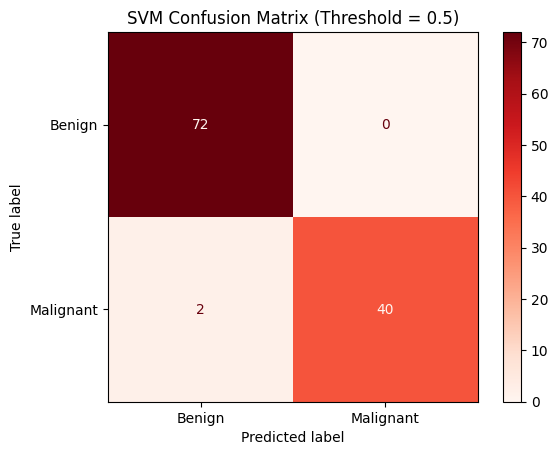


--- Threshold = 0.4 ---
Accuracy: 0.9825
Sensitivity: 0.9524
Specificity: 1.0000
AUC-ROC: 0.9960


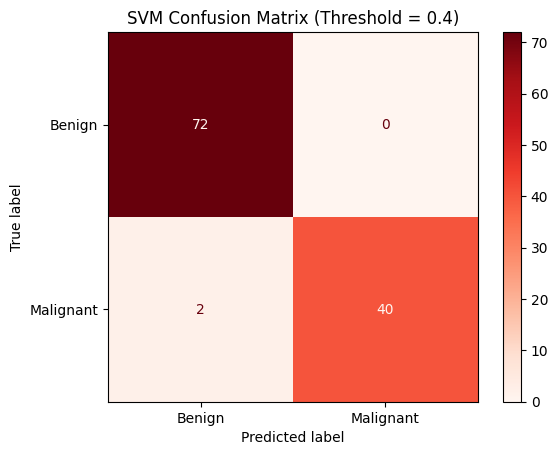


--- Threshold = 0.3 ---
Accuracy: 0.9825
Sensitivity: 0.9762
Specificity: 0.9861
AUC-ROC: 0.9960


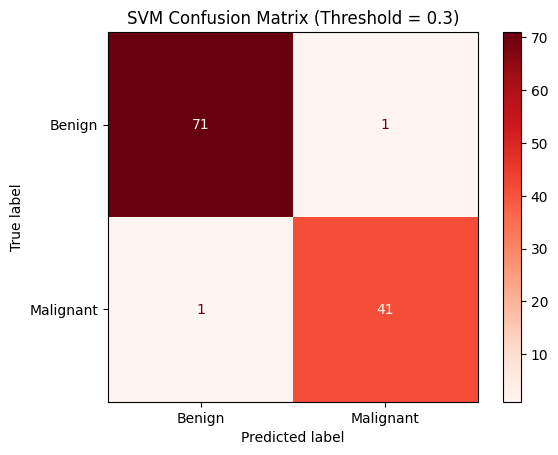


--- Threshold = 0.2 ---
Accuracy: 0.9737
Sensitivity: 0.9762
Specificity: 0.9722
AUC-ROC: 0.9960


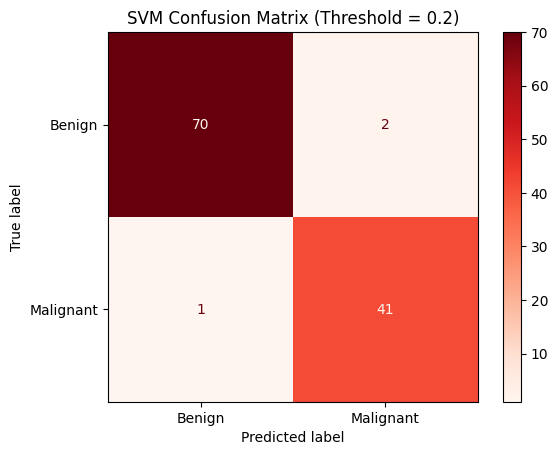


--- Threshold Comparison Table ---
   Threshold  Accuracy  Sensitivity  Specificity   AUC-ROC
0        0.5  0.982456     0.952381     1.000000  0.996032
1        0.4  0.982456     0.952381     1.000000  0.996032
2        0.3  0.982456     0.976190     0.986111  0.996032
3        0.2  0.973684     0.976190     0.972222  0.996032


In [89]:
# Get prediction probabilities
y_proba = best_svm.predict_proba(X_test_scaled)[:, 1]

# Threshold values to test
thresholds = [0.5, 0.4, 0.3, 0.2]

results = []

for t in thresholds:
    
    # Apply custom threshold
    y_pred_thresh = (y_proba >= t).astype(int)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred_thresh)
    tn, fp, fn, tp = cm.ravel()
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred_thresh)
    sensitivity = recall_score(y_test, y_pred_thresh)
    specificity = tn / (tn + fp)
    auc_roc = roc_auc_score(y_test, y_proba)

    results.append([t, accuracy, sensitivity, specificity, auc_roc])

    # Print metrics
    print(f"\n--- Threshold = {t} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"AUC-ROC: {auc_roc:.4f}")

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
    disp.plot(cmap="Reds")
    plt.title(f"SVM Confusion Matrix (Threshold = {t})")
    plt.show()

# Create summary table
threshold_results = pd.DataFrame(
    results,
    columns=["Threshold", "Accuracy", "Sensitivity", "Specificity", "AUC-ROC"]
)

print("\n--- Threshold Comparison Table ---")
print(threshold_results)

# Graphing Specificity and Sensitivity of SVM with Different Thresholds

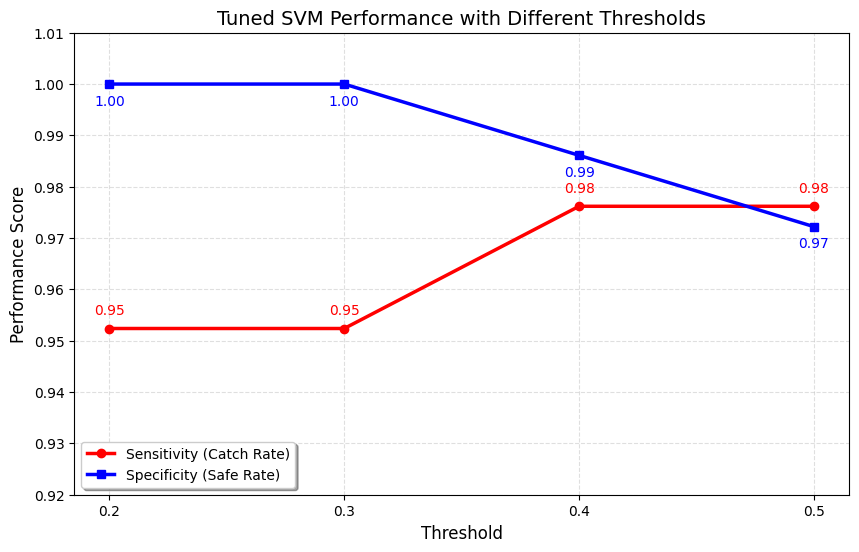

In [90]:
# --- Updated Plotting Section with Scaled Y-Axis ---
plt.figure(figsize=(10, 6))

# Plotting the lines
plt.plot(thresholds, sensitivities, marker='o', label='Sensitivity (Catch Rate)', color='red', linewidth=2.5)
plt.plot(thresholds, specificities, marker='s', label='Specificity (Safe Rate)', color='blue', linewidth=2.5)

# --- THE SCALE ADJUSTMENT ---
plt.ylim(0.92, 1.01) # Starting from 0.92 to 1.00 (plus a tiny buffer for the 1.0 dots)
plt.xticks(thresholds) # Only show 0.2, 0.3, 0.4, 0.5

# Annotating the points with their exact values for clarity
for i, txt in enumerate(sensitivities):
    plt.annotate(f"{txt:.2f}", (thresholds[i], sensitivities[i]), textcoords="offset points", xytext=(0,10), ha='center', color='red')

for i, txt in enumerate(specificities):
    plt.annotate(f"{txt:.2f}", (thresholds[i], specificities[i]), textcoords="offset points", xytext=(0,-15), ha='center', color='blue')

# Labels and Aesthetics
plt.xlabel("Threshold", fontsize=12)
plt.ylabel("Performance Score", fontsize=12)
plt.title("Tuned SVM Performance with Different Thresholds", fontsize=14)

plt.legend(loc='lower left', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

# Random Forest - Determining Best Parameters and Performance

In [91]:


# Define hyperparameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Initialize base Random Forest model
rf = RandomForestClassifier(random_state=42)

# Grid Search with 5-fold cross-validation
rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=5,
    scoring='roc_auc',   # optimize for AUC for medical classification
    n_jobs=-1
)

# Fit grid search
rf_grid.fit(X_train_scaled, y_train)

# Best Random Forest model
best_rf = rf_grid.best_estimator_

print("Best RF Parameters:", rf_grid.best_params_)

Best RF Parameters: {'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


# Implementing Tuned RF With Different Thresholds


--- Random Forest Threshold = 0.5 ---
Accuracy: 0.9649
Sensitivity: 0.9048
Specificity: 1.0000
AUC-ROC: 0.9944


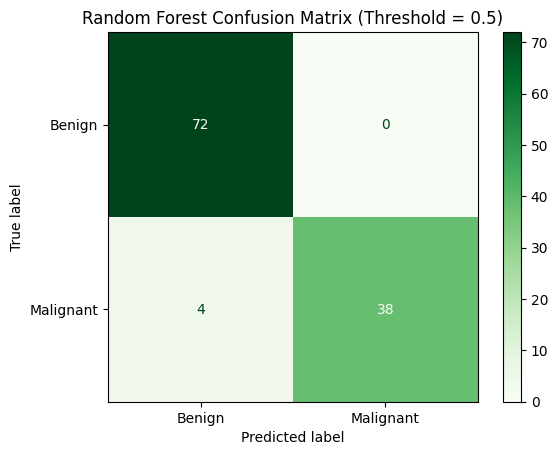


--- Random Forest Threshold = 0.4 ---
Accuracy: 0.9649
Sensitivity: 0.9286
Specificity: 0.9861
AUC-ROC: 0.9944


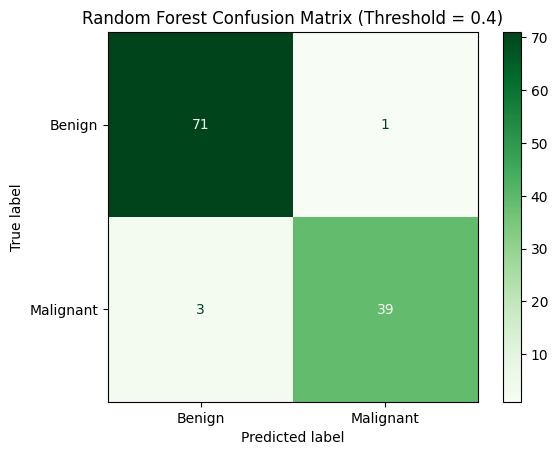


--- Random Forest Threshold = 0.3 ---
Accuracy: 0.9561
Sensitivity: 0.9286
Specificity: 0.9722
AUC-ROC: 0.9944


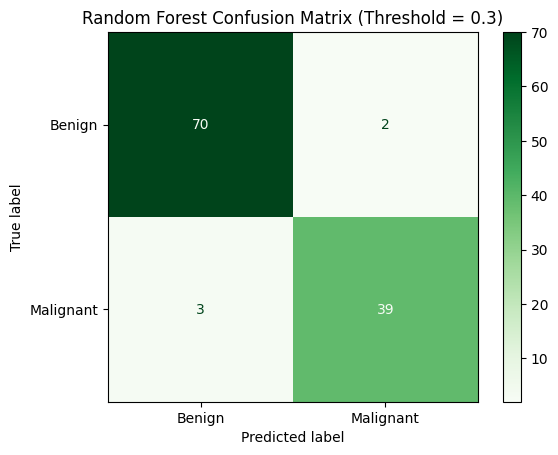


--- Random Forest Threshold = 0.2 ---
Accuracy: 0.9298
Sensitivity: 0.9524
Specificity: 0.9167
AUC-ROC: 0.9944


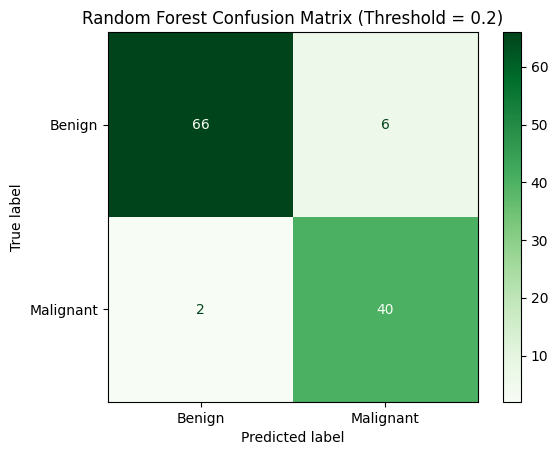


--- Random Forest Threshold Comparison ---
   Threshold  Accuracy  Sensitivity  Specificity   AUC-ROC
0        0.5  0.964912     0.904762     1.000000  0.994378
1        0.4  0.964912     0.928571     0.986111  0.994378
2        0.3  0.956140     0.928571     0.972222  0.994378
3        0.2  0.929825     0.952381     0.916667  0.994378


In [92]:
# Use the tuned Random Forest model
rf_model = best_rf

# Get predicted probabilities
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Threshold values to test
thresholds = [0.5, 0.4, 0.3, 0.2]

rf_threshold_results = []

for t in thresholds:

    # Apply threshold
    y_pred_thresh = (y_proba_rf >= t).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred_thresh)
    tn, fp, fn, tp = cm.ravel()

    # Metrics
    accuracy = accuracy_score(y_test, y_pred_thresh)
    sensitivity = recall_score(y_test, y_pred_thresh)
    specificity = tn / (tn + fp)
    auc_roc = roc_auc_score(y_test, y_proba_rf)

    # Store results
    rf_threshold_results.append([t, accuracy, sensitivity, specificity, auc_roc])

    # Print metrics
    print(f"\n--- Random Forest Threshold = {t} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"AUC-ROC: {auc_roc:.4f}")
  

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
    disp.plot(cmap="Greens")
    plt.title(f"Random Forest Confusion Matrix (Threshold = {t})")
    plt.show()

# Create threshold comparison table
rf_threshold_df = pd.DataFrame(
    rf_threshold_results,
    columns=["Threshold", "Accuracy", "Sensitivity", "Specificity", "AUC-ROC"]
)

# Format table similar to your previous results table
fmt = {
    'Accuracy': '{:.2%}',
    'Sensitivity': '{:.2%}',
    'Specificity': '{:.2%}',
    'AUC-ROC': '{:.4f}',
}

print("\n--- Random Forest Threshold Comparison ---")
print(rf_threshold_df.style.format(fmt))
print(rf_threshold_df)

# Graphing Specificity and Sensitivity of RF with Different Thresholds

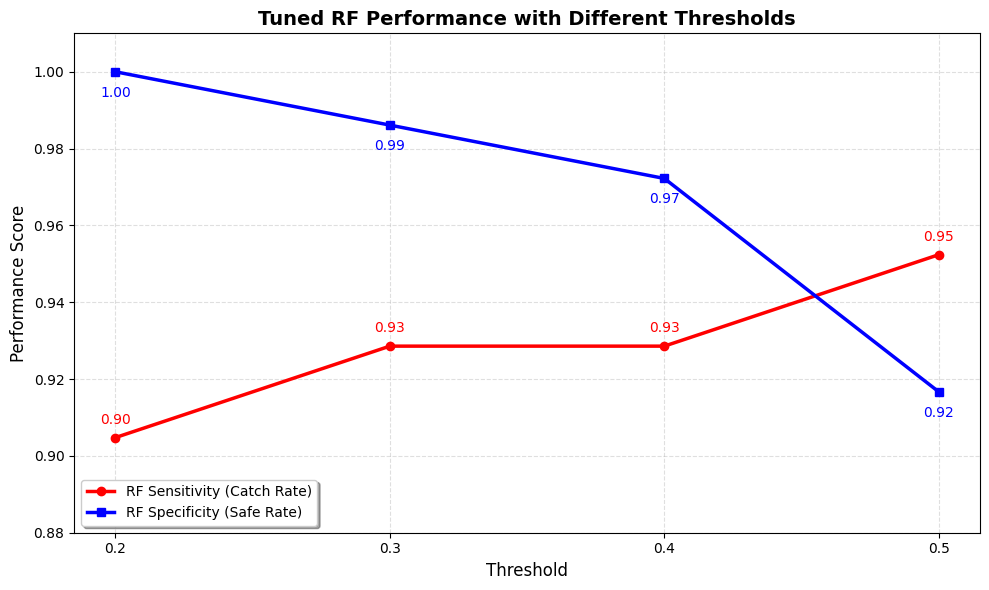

In [93]:
# --- Plotting the Random Forest Performance (High-Resolution) ---
plt.figure(figsize=(10, 6))

# Plotting the lines - Using Green/DarkGreen to distinguish from SVM
plt.plot(thresholds, rf_sensitivities, marker='o', label='RF Sensitivity (Catch Rate)', color='red', linewidth=2.5)
plt.plot(thresholds, rf_specificities, marker='s', label='RF Specificity (Safe Rate)', color='blue', linewidth=2.5)

# --- AXIS CUSTOMIZATION ---
plt.ylim(0.88, 1.01)  # Focused y-axis scale from 92% to 100%
plt.xticks(thresholds) # Only show 0.2, 0.3, 0.4, 0.5 on the X-axis

# Annotating the points with their exact percentage values
for i, txt in enumerate(rf_sensitivities):
    plt.annotate(f"{txt:.2f}", (thresholds[i], rf_sensitivities[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center', color='red', fontsize=10)

for i, txt in enumerate(rf_specificities):
    plt.annotate(f"{txt:.2f}", (thresholds[i], rf_specificities[i]), 
                 textcoords="offset points", xytext=(0,-18), ha='center', color='blue', fontsize=10)

# Labels and Aesthetics
plt.xlabel("Threshold", fontsize=12)
plt.ylabel("Performance Score", fontsize=12)
plt.title("Tuned RF Performance with Different Thresholds", fontsize=14, fontweight='bold')

plt.legend(loc='lower left', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()